<a href="https://colab.research.google.com/github/nayuanita/app-sidokter/blob/master/DataMiningUAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Analisis Diskursus Publik terhadap Serangan Ransomware Bank BSI Tahun 2023: Pendekatan K-Means Clustering dan IndoBERTweet**

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

**ANALISIS TOPIK**

In [ ]:
# =====================================
# SECTION 1: SETUP & DATA LOADING
# =====================================
import kagglehub
import os
import pandas as pd

# Download dataset
path = kagglehub.dataset_download("bashirhanafi/bank-bsi-tweets-sentiment-24k-tweets")
print("Path to dataset files:", path)
print(os.listdir(path))

# Load dataset
df = pd.read_csv(os.path.join(path, 'bsi_24k_tweets.csv'))
df.head()

100%|██████████| 1.98M/1.98M [00:00<00:00, 85.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bashirhanafi/bank-bsi-tweets-sentiment-24k-tweets/versions/1
['bsi_24k_tweets.csv']


,URL,Date,Tweet,ID,Username,Replies,Reetweets,Likes,Quotes,conversationId,Language,Links,Media,Retweeted Tweet,Bookmarks
0,https://twitter.com/SaidRberdaya/status/165898...,2023-05-17 23:40:12+00:00,@bankbsi_id Layanan BAYAR ke @TakafulKeluarga...,1658980771284279297,SaidRberdaya,0,0,0,0,1658830871812775937,in,NaN,NaN,NaN,0
1,https://twitter.com/ariemayw/status/1658980516...,2023-05-17 23:39:12+00:00,@NurmansyahAff @berlianidris @Paltiwest @bankb...,1658980516857802753,ariemayw,1,0,0,0,1658792156524425218,in,NaN,NaN,NaN,0
2,https://twitter.com/mputhreeeee/status/1658977...,2023-05-17 23:27:12+00:00,@bankbsi_id Udah bisa tarik tunai via ATM atau...,1658977499853000705,mputhreeeee,5,0,0,0,1658830871812775937,in,NaN,NaN,NaN,0
3,https://twitter.com/rahayusheeey/status/165897...,2023-05-17 23:18:39+00:00,@bankbsi_id Jangan lupa perbaiki mbanking untu...,1658975344765054976,rahayusheeey,4,0,0,0,1658830871812775937,in,NaN,NaN,NaN,0
4,https://twitter.com/ndaalfatih_/status/1658975...,2023-05-17 23:17:46+00:00,"@bankbsi_id Min, BSI udah amann dipake belum m...",1658975122894774272,ndaalfatih_,0,0,0,0,1658634424966344704,in,NaN,NaN,NaN,0


In [ ]:
# =====================================
# SECTION 2: PREPROCESSING SEBELUM LABELING
# =====================================
!pip install Sastrawi emoji -q

import nltk
import re
import emoji
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stemmer = StemmerFactory().create_stemmer()
stop_words = set(stopwords.words('indonesian'))
lemmatizer = WordNetLemmatizer()

def bersihkan_teks(teks):
    teks = str(teks).lower()
    teks = emoji.replace_emoji(teks, '')
    teks = re.sub(r"http\S+|www\S+|https\S+", '', teks)
    teks = re.sub(r'\@\w+|\#', '', teks)
    teks = re.sub(r'(.)\1{2,}', r'\1\1', teks)
    teks = re.sub(r'[^a-z\s]', '', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    return teks

# Apply cleaning awal untuk semua data
df['tweet_clean1'] = df['Tweet'].apply(bersihkan_teks)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 18.8 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
# =====================================
# SECTION 3: LABELING MANUAL
# =====================================
df_sample = df[['tweet_clean1']].dropna().sample(n=1000, random_state=42)
df_sample['original_index'] = df_sample.index

df_sample = df_sample.reset_index(drop=True)
df_sample['label'] = ''
df_sample.to_csv('data_labeling_awal.csv', index=False)

# Untuk upload manual labeling (jika sudah diisi)
from google.colab import files
uploaded = files.upload()

# Import label manual ke dataframe utama
df_label = pd.read_csv('Labeling_1.csv')
for i, row in df_label.iterrows():
    df.loc[row['original_index'], 'label'] = row['label']

Saving Labeling_1.csv to Labeling_1.csv


In [ ]:
# =====================================
# SECTION 4: EMBEDDING UNTUK TOPIC CLUSTERING
# =====================================
!pip install tqdm transformers -q
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

# Load model dan tokenizer IndoBERTweet
model_name = "indolem/indobertweet-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

def generate_embeddings_batch(texts, batch_size=32):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating Embeddings"):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**encoded)
            batch_embeddings = outputs.last_hidden_state.mean(dim=1).numpy()
            all_embeddings.append(batch_embeddings)
    return np.vstack(all_embeddings)

# Gunakan tweet_clean1 untuk representasi topik
embeddings = generate_embeddings_batch(df['tweet_clean1'].tolist(), batch_size=32)
np.save("tweet_embeddings.npy", embeddings)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Generating Embeddings:   0%|          | 0/763 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Generating Embeddings: 100%|██████████| 763/763 [34:43<00:00,  2.73s/it]


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


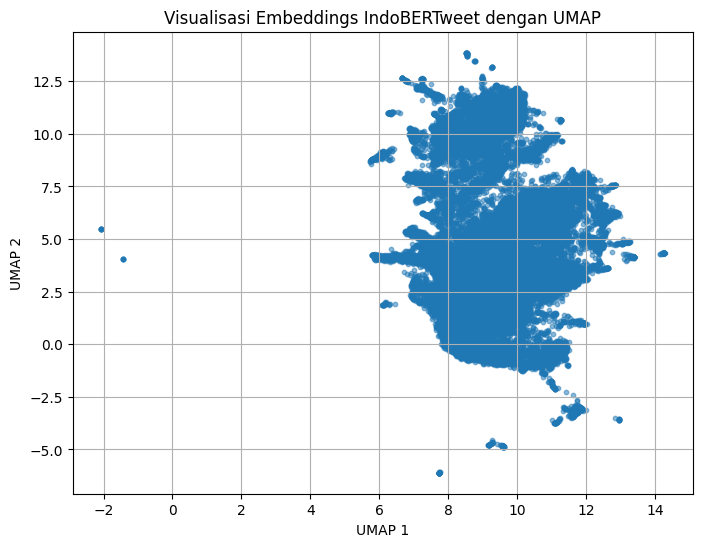

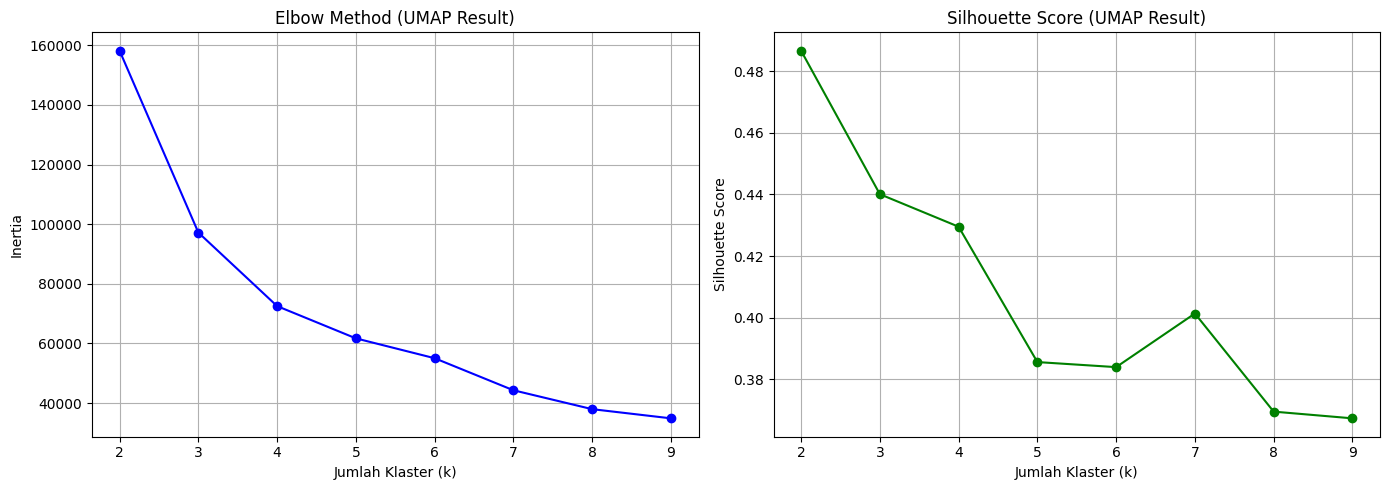

Jumlah klaster terbaik menurut Silhouette Score: 2


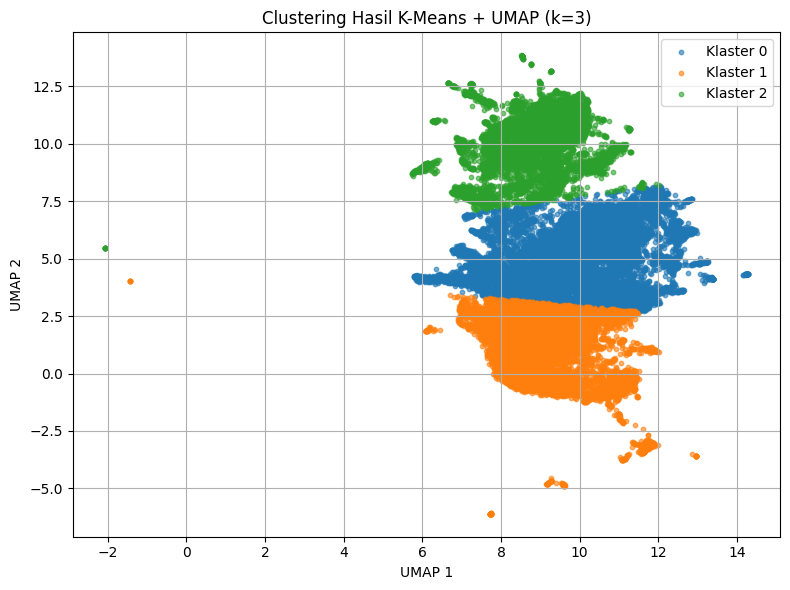

Silhouette Score (UMAP + K-Means): 0.440


In [ ]:
# =====================================
# SECTION 4B: UMAP REDUCTION (DENGAN NOISE)
# =====================================
import umap.umap_ as umap
import numpy as np
import matplotlib.pyplot as plt

# Tambahkan noise kecil untuk stabilisasi
np.random.seed(42)
noise = np.random.normal(loc=0, scale=1e-5, size=embeddings.shape)
embeddings_noisy = embeddings + noise

# Reduksi dimensi embeddings ke 2D
umap_model = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
umap_result = umap_model.fit_transform(embeddings_noisy)

df['umap1'] = umap_result[:, 0]
df['umap2'] = umap_result[:, 1]

# Visualisasi UMAP (tanpa clustering dulu)
plt.figure(figsize=(8, 6))
plt.scatter(df['umap1'], df['umap2'], s=10, alpha=0.5)
plt.title('Visualisasi Embeddings IndoBERTweet dengan UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True)
plt.show()

# =====================================
# SECTION 4C: EVALUASI K OPTIMAL UNTUK UMAP+KMEANS
# =====================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias_umap = []
silhouette_scores_umap = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(umap_result)
    inertias_umap.append(kmeans.inertia_)

    if len(set(labels)) > 1:
        score = silhouette_score(umap_result, labels)
    else:
        score = -1
    silhouette_scores_umap.append(score)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(K, inertias_umap, 'bo-')
plt.xlabel("Jumlah Klaster (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (UMAP Result)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores_umap, 'go-')
plt.xlabel("Jumlah Klaster (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score (UMAP Result)")
plt.grid(True)

plt.tight_layout()
plt.show()

best_k = K[silhouette_scores_umap.index(max(silhouette_scores_umap))]
print(f"Jumlah klaster terbaik menurut Silhouette Score: {best_k}")

# =====================================
# SECTION 4D: K-MEANS on UMAP
# =====================================
kmeans_umap = KMeans(n_clusters=3, random_state=42)
labels_umap_kmeans = kmeans_umap.fit_predict(umap_result)
df['cluster_umap_kmeans'] = labels_umap_kmeans

# Visualisasi hasil clustering dengan label legend per klaster
plt.figure(figsize=(8, 6))
for cluster_label in sorted(df['cluster_umap_kmeans'].unique()):
    subset = df[df['cluster_umap_kmeans'] == cluster_label]
    plt.scatter(subset['umap1'], subset['umap2'],
                s=10, alpha=0.6, label=f'Klaster {cluster_label}')

plt.title(f'Clustering Hasil K-Means + UMAP (k=3)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

score_kmeans_umap = silhouette_score(umap_result, labels_umap_kmeans)
print(f"Silhouette Score (UMAP + K-Means): {score_kmeans_umap:.3f}")

In [ ]:
# =====================================
# SECTION 5: KLASTERISASI
# =====================================
# Distribusi jumlah tweet per klaster
distribusi_klaster = df['cluster_umap_kmeans'].value_counts().sort_index()
print("Distribusi Tweet per Klaster:")
for klaster, jumlah in distribusi_klaster.items():
    print(f"- Klaster {klaster}: {jumlah} tweet")

# Tweet Paling Representatif per Klaster
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("\nTweet Paling Representatif per Klaster:\n")

for i in range(kmeans_umap.n_clusters):
    # Ambil pusat klaster di ruang UMAP
    centroid = kmeans_umap.cluster_centers_[i].reshape(1, -1)

    # Ambil indeks tweet di klaster i
    cluster_indices = df[df['cluster_umap_kmeans'] == i].index
    cluster_umap_vectors = umap_result[cluster_indices]

    # Hitung cosine similarity antara tiap tweet dan centroid
    similarities = cosine_similarity(cluster_umap_vectors, centroid).flatten()

    # Ambil indeks tweet yang paling mirip dengan centroid (representatif)
    top_idx = similarities.argsort()[-50:]  # Ambil 10 teratas
    tweet_idx = cluster_indices[top_idx]

    print(f"\n===== Klaster {i} (Tweet Paling Representatif) =====")
    for idx in tweet_idx:
        print(f"- {df.loc[idx, 'tweet_clean1']}")
    print("-" * 80)

Distribusi Tweet per Klaster:
- Klaster 0: 10439 tweet
- Klaster 1: 7646 tweet
- Klaster 2: 6316 tweet

Tweet Paling Representatif per Klaster:


===== Klaster 0 (Tweet Paling Representatif) =====
- drpd simpen duit di gw lebih ngerasa aman nabung di bpr
- kayaknya ini karena pemulihannya belum semua deh kak tapi ada beberapa atm yang udah bisa kok saranku cek lagi aja nanti
- di teller pun juga gabisa kak
- tdi ke bank nyoba cek mutasi buku tabungan krna ga make atm mbanking emg sengaja buat nabung si tp alhamdulillah aman
- kapan internet banking bisa aktif
- saatnya beralih ke bank lain wkwk
- info dari orang orang juga udah bisa lagi kak atmnya bisa dipake lagi buat tarik tunai coba cek ajaa nanti
- masih proses normalisasi sepertinya ka aku juga nungguin sama ini berdoa aja biar cepet pulih di cek berkala aja ka
- kalau internet banking msh blm bisa yaa
- jangan lupa kosongkan saldo setelah layanan up bankrun
- bang ini kapan mobile banking normal lagi semoga saldo aman aja
- m ba

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-8-3257565442.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
10,0.643700
20,0.557200
30,0.499400
40,0.465200
50,0.418900
60,0.384900
70,0.318700
80,0.264000
90,0.276700
100,0.222900


              precision    recall  f1-score   support

     negatif       0.91      0.92      0.92       141
 non-negatif       0.81      0.78      0.79        59

    accuracy                           0.88       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.88      0.88      0.88       200



=== Evaluasi di Data Training ===
              precision    recall  f1-score   support

     negatif       0.97      0.97      0.97       565
 non-negatif       0.92      0.93      0.93       235

    accuracy                           0.96       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.96      0.96      0.96       800



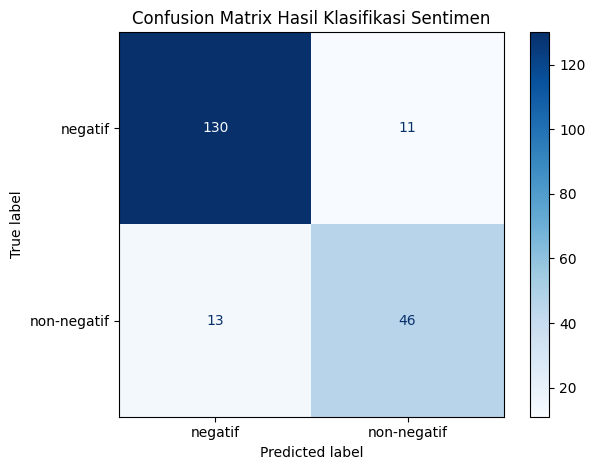

In [ ]:
# =====================================
# SECTION 6: SENTIMENT CLASSIFICATION (FINE-TUNING)
# =====================================
import random
import numpy as np
import torch
from transformers import set_seed, AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Set random seed untuk stabilitas hasil
SEED = 40
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Siapkan data label
df_labeled = df[df['label'].notnull() & (df['label'] != '')].copy()
df_labeled['label'] = df_labeled['label'].map({'negatif': 0, 'non-negatif': 1})

train_df, test_df = train_test_split(df_labeled, test_size=0.2, stratify=df_labeled['label'], random_state=42)

# Dataset HF
train_ds = Dataset.from_pandas(train_df[['tweet_clean1', 'label']].rename(columns={"tweet_clean1": "text"}))
test_ds = Dataset.from_pandas(test_df[['tweet_clean1', 'label']].rename(columns={"tweet_clean1": "text"}))

def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

model_cls = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",
    seed=SEED,
    save_strategy="no"  # untuk mempercepat (bisa diganti kalau ingin simpan model)
)

trainer = Trainer(
    model=model_cls,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer
)

trainer.train()

# Evaluasi
preds_output = trainer.predict(test_ds)
preds = torch.tensor(preds_output.predictions).softmax(dim=1).argmax(dim=1).numpy()
y_true = test_ds['label']
print(classification_report(y_true, preds, target_names=["negatif", "non-negatif"]))

# Evaluasi di data training (opsional)
train_preds_output = trainer.predict(train_ds)
train_preds = torch.tensor(train_preds_output.predictions).softmax(dim=1).argmax(dim=1).numpy()
train_true = train_ds['label']

print("=== Evaluasi di Data Training ===")
print(classification_report(train_true, train_preds, target_names=["negatif", "non-negatif"]))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Buat confusion matrix
cm = confusion_matrix(y_true, preds)

# Tampilkan dalam bentuk visual
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negatif", "non-negatif"])
disp.plot(cmap="Blues", values_format='d')

plt.title("Confusion Matrix Hasil Klasifikasi Sentimen")
plt.grid(False)
plt.tight_layout()
plt.show()

Device set to use cuda:0
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


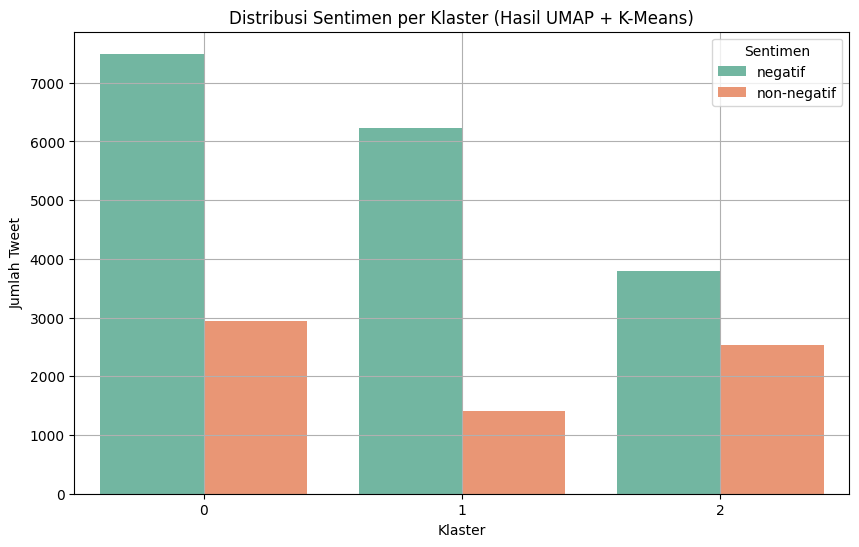

In [ ]:
# =====================================
# SECTION 7: Pelabelan Otomatis & Distribusi Sentimen per Klaster
# =====================================
from transformers import TextClassificationPipeline
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Buat pipeline klasifikasi dari model hasil fine-tune
pipe_sentiment = TextClassificationPipeline(
    model=model_cls,
    tokenizer=tokenizer,
    return_all_scores=False,
    #function_to_apply='softmax', nanti coba run
    device=0 if torch.cuda.is_available() else -1
)

# 2. Prediksi sentimen untuk semua tweet (gunakan tweet_clean1)
df['predicted_sentiment'] = df['tweet_clean1'].apply(lambda x: pipe_sentiment(x)[0]['label'])

# 3. Ubah label dari format 'LABEL_0' / 'LABEL_1' ke 'negatif' / 'non-negatif'
label_map = {'LABEL_0': 'negatif', 'LABEL_1': 'non-negatif'}
df['predicted_sentiment'] = df['predicted_sentiment'].map(label_map)

# 4. Visualisasi distribusi sentimen berdasarkan klaster hasil KMeans+UMAP
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='cluster_umap_kmeans', hue='predicted_sentiment', palette='Set2')
plt.title('Distribusi Sentimen per Klaster (Hasil UMAP + K-Means)')
plt.xlabel('Klaster')
plt.ylabel('Jumlah Tweet')
plt.legend(title='Sentimen')
plt.grid(True)
plt.show()


In [ ]:
# ===========================
# SECTION 8: Ringkasan Hasil Sentimen
# ===========================

# 1. Distribusi sentimen keseluruhan
total_counts = df['predicted_sentiment'].value_counts()
total_percent = df['predicted_sentiment'].value_counts(normalize=True) * 100

print("Distribusi Sentimen (Keseluruhan):")
for label in total_counts.index:
    print(f"- {label}: {total_counts[label]} tweet ({total_percent[label]:.2f}%)")

# 2. Distribusi sentimen per klaster
print("\nDistribusi Sentimen per Klaster:")
clusters = sorted(df['cluster_umap_kmeans'].unique())
for cluster in clusters:
    sub = df[df['cluster_umap_kmeans'] == cluster]
    counts = sub['predicted_sentiment'].value_counts()
    percent = sub['predicted_sentiment'].value_counts(normalize=True) * 100
    print(f"\nKlaster {cluster} (n={len(sub)}):")
    for label in counts.index:
        print(f"- {label}: {counts[label]} tweet ({percent[label]:.2f}%)")

Distribusi Sentimen (Keseluruhan):
- negatif: 17512 tweet (71.77%)
- non-negatif: 6889 tweet (28.23%)

Distribusi Sentimen per Klaster:

Klaster 0 (n=10439):
- negatif: 7493 tweet (71.78%)
- non-negatif: 2946 tweet (28.22%)

Klaster 1 (n=7646):
- negatif: 6233 tweet (81.52%)
- non-negatif: 1413 tweet (18.48%)

Klaster 2 (n=6316):
- negatif: 3786 tweet (59.94%)
- non-negatif: 2530 tweet (40.06%)
